
<style>
.box { border-radius: 10px; padding: 14px 18px; margin: 12px 0; font-size: 13px; }
.info   { background: #142F63; border-left: 4px solid #4988C4; }
.warn   { background: #142F63; border-left: 4px solid #E8C56A; }
.key    { background: #142F63; border-left: 4px solid #BDE8F5; }
.ok     { background: #142F63; border-left: 4px solid #4CD98C; }
.attrib { background: #142F63; border: 1px solid #24406B; border-left: 4px solid #BDE8F5; }
.box b { color: #BDE8F5; }
h1 { color: #BDE8F5; }
h2 { color: #4988C4; border-bottom: 2px solid #24406B; padding-bottom: 6px; }
h3 { color: #BDE8F5; }
table { border-collapse: collapse; width: 100%; }
th { background: #1C4D8D; color: #BDE8F5; padding: 8px 12px; text-align: left; }
td { padding: 6px 12px; border-bottom: 1px solid #24406B; }
code { color: #BDE8F5; }
</style>


<div style="background:linear-gradient(135deg,#1C4D8D 0%,#0F2854 60%,#142F63 100%);border-radius:14px;padding:28px 32px;border:1px solid #24406B;">
<div style="font-size:11px;letter-spacing:3px;color:#BDE8F5;text-transform:uppercase;margin-bottom:8px;">AI Tools Course</div>
<div style="font-size:26px;font-weight:700;color:#F8FAFC;margin-bottom:8px;">AI-Powered Oral Disease Detection System</div>
<div style="font-size:17px;color:#BDE8F5;margin-bottom:14px;">Milestone 3 &middot; Model Training (Four-Architecture Transfer-Learning Benchmark)</div>
<div style="font-size:13px;color:#CBD5E1;">Custom CNN &middot; MobileNetV2 &middot; EfficientNetB3 &middot; DenseNet121 &mdash; trained on the verified Milestone 2 pipeline</div>
</div>


<div style="background:#142F63;border:1px solid #24406B;border-radius:12px;padding:16px 22px;margin:14px 0;">
<div style="font-size:13px;font-weight:700;color:#BDE8F5;margin-bottom:10px;letter-spacing:1px;text-transform:uppercase;">Table of Contents</div>
<table>
<tr><td><a href="#sec-intro">1 &middot; Introduction</a></td><td><a href="#sec-cnn">6.1 &middot; Custom CNN</a></td><td><a href="#sec-dense">6.4 &middot; DenseNet121</a></td></tr>
<tr><td><a href="#sec-ref">2 &middot; Our Contribution</a></td><td><a href="#sec-mobile">6.2 &middot; MobileNetV2</a></td><td><a href="#sec-compare">7 &middot; Architecture Comparison</a></td></tr>
<tr><td><a href="#sec-dl">3 &middot; Why Deep Learning?</a></td><td><a href="#sec-eff">6.3 &middot; EfficientNetB3</a></td><td><a href="#sec-bench">8 &middot; Training Workflow</a></td></tr>
<tr><td><a href="#sec-tl">4 &middot; Transfer Learning</a></td><td><a href="#sec-data">5 &middot; Data Loading (M2)</a></td><td><a href="#sec-results">9 &middot; Benchmark Results</a></td></tr>
<tr><td><a href="#sec-select">10 &middot; Model Selection</a></td><td><a href="#sec-inventory">11 &middot; Artifacts &amp; Next Steps</a></td><td></td></tr>
</table>
</div>


<div id="sec-intro"></div><div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div><h2 style="font-size:21px;color:#BDE8F5;">1 &middot; Introduction</h2>

Milestone 3 integrates a four-architecture training benchmark: a from-scratch <b>Custom CNN</b>, plus
three transfer-learning models &mdash; <b>MobileNetV2</b>, <b>EfficientNetB3</b>
and <b>DenseNet121</b>.



### Objectives

| # | Objective |
| --- | --- |
| 1 | Preserve the training implementation (4 models, callbacks, workflow) |
| 2 | Adapt data loading to our verified M2 pipeline &mdash; no splits regenerated |
| 3 | Keep the comparison workflow with published benchmark values |
| 4 | Document why each architecture was selected and how transfer learning works |
| 5 | Produce artifacts ready for Milestone 4 (held-out evaluation) |

### Roadmap

| Milestone | Deliverable | Status |
| --- | --- | --- |
| 1 | EDA + design system | &#10004; approved |
| 2 | Preprocessing pipeline (verified) | &#10004; approved |
| 3 | Four-architecture training benchmark | <b>this notebook</b> |
| 4 | Evaluation (metrics, confusion matrix, test set) | next |
| 5 | Grad-CAM explainability + Streamlit | later |


<div id="sec-ref"></div><div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div><h2 style="font-size:21px;color:#BDE8F5;">2 &middot; Our Contribution &amp; Our Contribution</h2>

### What we adopt from the benchmark

The benchmark notebook defines a complete training benchmark. We adopt its
<b>engineering decisions</b> verbatim because they are sound and proven:

| Decision | Value |
| --- | --- |
| Baseline first | Custom CNN establishes the floor before transfer learning |
| Two-phase training (MobileNetV2) | Frozen feature extraction, then full fine-tuning at 10&times; lower LR |
| Partial fine-tuning | EfficientNetB3 top-50 and DenseNet121 last-40 layers unfrozen |
| Per-architecture preprocessing | [-1,1] rescale for MobileNetV2, built-in for EfficientNet, mean-subtraction for DenseNet |
| Smart callbacks | EarlyStopping, ModelCheckpoint (best weights), ReduceLROnPlateau |
| Comparison workflow | Champion selection from validation accuracy |

### What we change (integration only)

| Aspect | Original | This project |
| --- | --- | --- |
| Dataset path | the M2 data directory | <code>Oral Diseases/</code> via M2 partition file |
| Split | Random 80/20, seed 123 | <b>Stratified 70/15/15, seed 42, persisted</b> (M2) |
| Pipeline | <code>image_dataset_from_directory</code> | M2 tf.data contract (decode &rarr; 224&times;224 &rarr; float32 [0,255]) |
| Deprecated APIs | <code>InputLayer(input_shape=)</code>, <code>verbose=1</code> | Modern equivalents (<code>shape=</code>, no <code>verbose</code>) |
| Result handling | Hardcoded fallback accuracies | Removed &mdash; comparison falls back to clearly labeled published values |
| Outputs | Notebook working directory | <code>models/</code>, <code>reports/</code>, <code>artifacts/</code> |

<div class="box key">No benchmark content is presented as our own work. Benchmark metrics are &quot;Published Benchmarkn Results&quot; throughout the notebook, report and presentation.</div>


In [4]:
# ============================================================================
# SETUP - Imports, Project Paths, Design System, Reproducibility
# ============================================================================

import json
import sys
import time
from pathlib import Path

# -----------------------------------------------------------------------------
# Locate Project Root Automatically
# -----------------------------------------------------------------------------

CURRENT = Path.cwd()

# Running from project root
if (CURRENT / "src").exists():
    ROOT = CURRENT

# Running from notebooks/
elif (CURRENT.parent / "src").exists():
    ROOT = CURRENT.parent

else:
    raise FileNotFoundError(
        "Could not locate the project's 'src' directory.\n"
        "Run this notebook from either:\n"
        "  • Project Root\n"
        "  • notebooks/\n"
    )

SRC = ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("=" * 70)
print("Project Root :", ROOT)
print("Source Folder:", SRC)
print("Style Module :", SRC / "project_style.py")
print("Exists       :", (SRC / "project_style.py").exists())
print("=" * 70)

# -----------------------------------------------------------------------------
# Standard Imports
# -----------------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# -----------------------------------------------------------------------------
# Project Design System
# -----------------------------------------------------------------------------

from project_style import (
    apply_style,
    CHART_COLORS,
    BG_PRIMARY as BG,
    BG_PANEL as PANEL,
    ACCENT_PRIMARY as ACCENT,
    ACCENT_SECONDARY as SECONDARY,
    HIGHLIGHT,
    TEXT_PRIMARY as TEXT,
    TEXT_SECONDARY as MUTED,
    GRID_COLOR as GRID,
    POSITIVE_COLOR as POSITIVE,
)

apply_style()

# -----------------------------------------------------------------------------
# Reproducibility
# -----------------------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print(f"TensorFlow Version : {tf.__version__}")

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print(f"GPU Available      : {len(gpus)}")
    for gpu in gpus:
        print(f"  - {gpu.name}")
else:
    print("GPU Available      : CPU Only")

print("Random Seed        :", SEED)

# -----------------------------------------------------------------------------
# Project Constants
# -----------------------------------------------------------------------------

IMG_SIZE = 224
BATCH_SIZE = 32

REPORTS_DIR = ROOT / "reports"
MODELS_DIR = ROOT / "models"
ARTIFACTS_DIR = ROOT / "artifacts"

REPORTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR.mkdir(exist_ok=True)

# -----------------------------------------------------------------------------
# Chart Helpers
# -----------------------------------------------------------------------------

def save_chart(fig, filename: str) -> None:
    """
    Save a matplotlib figure using the project's design system.
    """
    output_path = REPORTS_DIR / filename

    fig.savefig(
        output_path,
        dpi=160,
        bbox_inches="tight",
        facecolor=BG,
    )

    print(f"Saved: {output_path}")


def display_chart(fig, filename: str) -> None:
    """
    Save and display a chart.
    """
    save_chart(fig, filename)
    plt.show()
    plt.close(fig)

print("\nEnvironment initialized successfully.")

Project Root : d:\AI Tools _project
Source Folder: d:\AI Tools _project\src
Style Module : d:\AI Tools _project\src\project_style.py
Exists       : True
TensorFlow Version : 2.21.0
GPU Available      : CPU Only
Random Seed        : 42

Environment initialized successfully.


<div id="sec-dl"></div><div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div><h2 style="font-size:21px;color:#BDE8F5;">3 &middot; Why Deep Learning for Oral Disease Classification?</h2>

Oral disease diagnosis from clinical photographs is difficult for rule-based
systems: lesions vary in shape, color, size and lighting, and the visual cues
overlap between conditions (e.g. early caries vs. discoloration).

| Why CNNs | Benefit for oral images |
| --- | --- |
| Learned features, not hand-crafted | No manual feature engineering for texture/color cues |
| Translation invariance | Disease can appear anywhere in the frame |
| Hierarchical abstraction | Edges &rarr; textures &rarr; lesion-level patterns |
| Pretrained backbones | Small medical datasets still reach strong accuracy via transfer learning |

The benchmark demonstrates the standard protocol: start from a
from-scratch baseline, then show how ImageNet-pretrained models lift accuracy
through transfer learning.


<div id="sec-tl"></div><div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div><h2 style="font-size:21px;color:#BDE8F5;">4 &middot; Transfer Learning Explained</h2>

Medical image datasets are far smaller than ImageNet (~1.2 M images). Training
a deep network from scratch would overfit or converge very slowly. Transfer
learning reuses a network already trained on ImageNet: its early layers encode
<b>generic visual features</b> (edges, colors, textures) that transfer to any
vision task.

### The standard recipe used by all three pretrained models

1. <b>Load</b> the backbone with ImageNet weights, drop its 1000-class head.
2. <b>Freeze</b> (or partially freeze) the backbone; attach a small custom head
   (GlobalAveragePooling &rarr; Dense &rarr; Dropout &rarr; softmax).
3. <b>Train the head</b> first &mdash; the frozen backbone cannot overfit or drift.
4. <b>Fine-tune</b> the top backbone layers at a 10&times; lower learning rate so
   the pretrained features adapt to oral-disease textures without destructive updates.

### Why partial unfreezing?

The first blocks of a pretrained network hold generic filters (edges, colors)
that transfer perfectly and should stay frozen. The final blocks hold the most
task-specific features and benefit most from adaptation &mdash; so the
notebook unfreezes only the top layers (MobileNetV2: all; EfficientNetB3:
top 50; DenseNet121: last 40).

<div class="box info">Each backbone also applies its own preprocessing contract. Our M2 pipeline feeds float32 in [0,255]; the models normalize internally &mdash; the model's MobileNetV2 scales to [-1,1], DenseNet121 subtracts ImageNet means, and EfficientNet normalizes with built-in layers. This is why M2 kept pixels in [0,255].</div>


<div id="sec-data"></div><div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div><h2 style="font-size:21px;color:#BDE8F5;">5 &middot; Data Loading - Exact Milestone 2 Split</h2>

The data contract is inherited from Milestone 2 &mdash; nothing is regenerated:

| Artifact | Content |
| --- | --- |
| <code>reports/split_partition.npz</code> | Exact train/val/test paths + labels (seed 42) |
| <code>reports/split_metadata.json</code> | Seed, ratios, class map, counts |
| Class map | Calculus, Caries, Gingivitis, Ulcers, Tooth Discoloration, Hypodontia |

- Train 8,624 &middot; validation 1,848 &middot; <b>test 1,848 (reserved for M4)</b>.
- Pipeline: decode &rarr; resize 224&times;224 &rarr; float32 [0,255] &rarr;
  cache &rarr; shuffle &rarr; batch(32) &rarr; prefetch(AUTOTUNE).
- <b>Augmentation is embedded inside each model</b> (standard strategy), so the
  pipeline adds none &mdash; applying both would change the training distribution.

<div class="box warn">The training proceeds without class weights to keep the benchmark comparable with its published results. Class imbalance (2.24:1) was quantified in M1/M2 and per-class performance will be analysed in Milestone 4.</div>


In [5]:
# ============================================================================
# 5. LOAD THE EXACT MILESTONE 2 SPLIT (never regenerated)
# ============================================================================
# The stratified 70/15/15 partition (seed 42) was produced once in Milestone 2
# and is loaded here verbatim. The test split (1,848 images) is NEVER used in
# this notebook - it is reserved for Milestone 4 evaluation.
split_meta = json.loads(Path("reports/split_metadata.json").read_text(encoding="utf-8"))
parts = np.load("reports/split_partition.npz", allow_pickle=False)

class_map = split_meta["class_map"]            # folder -> disease name
class_names = list(class_map.values())
NUM_CLASSES = len(class_names)
print("Class map (label order):")
for i, (folder, name) in enumerate(class_map.items()):
    print(f"  {i}: {name:<22} ({folder})")

train_paths = [str(p) for p in parts["train_paths"]]
val_paths = [str(p) for p in parts["val_paths"]]
train_labels = parts["train_labels"].astype("int32")
val_labels = parts["val_labels"].astype("int32")

assert split_meta["seed"] == SEED
print(f"Split loaded: train {len(train_paths):,} | val {len(val_paths):,} "
      f"(test {split_meta['test']:,} reserved for M4)")

# ---- Rebuild the M2 pipeline contract --------------------------------------
# Decode RGB -> resize 224x224 -> float32 in [0,255] (M2 contract; each model
# normalizes internally, exactly as in the training implementation).
def load_and_preprocess(path: str, label: int) -> tuple:
    """Decode RGB, resize 224x224, cast float32 in [0,255] (M2 contract)."""
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return tf.cast(image, tf.float32), label


def make_dataset(paths, labels) -> tf.data.Dataset:
    """tf.data pipeline: map -> cache -> shuffle -> batch -> prefetch.

    Augmentation is intentionally NOT applied here: every model in this
    benchmark embeds its own augmentation layers (standard strategy), so
    applying it twice would change the training distribution.
    """
    ds = tf.data.Dataset.from_tensor_slices(
        (tf.constant(paths), tf.constant(labels, dtype=tf.int32)))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache().shuffle(2048).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_paths, train_labels)
val_ds = make_dataset(val_paths, val_labels)

sample = next(iter(train_ds))
print("Sample batch:", sample[0].shape, sample[0].dtype,
      f"range [{sample[0].numpy().min():.0f}, {sample[0].numpy().max():.0f}]")
print("Pipeline ready (identical transforms to Milestone 2)")


Class map (label order):
  0: Calculus               (Calculus)
  1: Caries                 (Data caries)
  2: Gingivitis             (Gingivitis)
  3: Ulcers                 (Mouth Ulcer)
  4: Tooth Discoloration    (Tooth Discoloration)
  5: Hypodontia             (hypodontia)
Split loaded: train 8,624 | val 1,848 (test 1,848 reserved for M4)
Sample batch: (32, 224, 224, 3) <dtype: 'float32'> range [0, 255]
Pipeline ready (identical transforms to Milestone 2)


In [6]:
# ============================================================================
# TRAINING UTILITIES (project theme)
# ============================================================================
def plot_history(history, model_name: str = "Model", save_path: str = None) -> None:
    """Plot training/validation accuracy and loss from a Keras History."""
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    axes[0].plot(epochs, acc, marker="o", color=SECONDARY, label="training")
    axes[0].plot(epochs, val_acc, marker="s", color=HIGHLIGHT, label="validation")
    axes[0].set_title(f"{model_name} - Accuracy", color=HIGHLIGHT)
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("accuracy")
    axes[0].legend(facecolor=BG, labelcolor=TEXT)

    axes[1].plot(epochs, loss, marker="o", color=SECONDARY, label="training")
    axes[1].plot(epochs, val_loss, marker="s", color=HIGHLIGHT, label="validation")
    axes[1].set_title(f"{model_name} - Loss", color=HIGHLIGHT)
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("loss")
    axes[1].legend(facecolor=BG, labelcolor=TEXT)

    fig.tight_layout()
    if save_path:
        display_chart(fig, save_path)
    else:
        plt.show()
        plt.close(fig)


<div id="sec-cnn"></div><div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div><h2 style="font-size:21px;color:#BDE8F5;">6.1 &middot; Architecture 1 - Custom CNN (Baseline)</h2>

### Why this model was selected

Every benchmarking study needs a baseline. The custom CNN is trained
<b>from scratch</b> with no pretrained knowledge and therefore answers the
central question: <i>how much does transfer learning actually help on our
data?</i> It also validates the data pipeline end-to-end before expensive
pretrained models are loaded.

### Design

Four convolutional blocks (32 &rarr; 64 &rarr; 128 &rarr; 256 filters), each
with <code>BatchNormalization</code> and <code>MaxPooling</code>, followed by a
256-unit dense layer with Dropout 0.4 and a softmax head. Augmentation
(flip/rotation/zoom) and rescaling to [0,1] are embedded in the model.

### Strengths

- Small, fast, fully transparent &mdash; every parameter is learned from our data.
- Measures the true contribution of transfer learning.

### Limitations

- ~13.2 M parameters, dominated by the <code>Flatten &rarr; Dense(256)</code>
  transition (12.8 M) &mdash; the most overfitting-prone part.
- No pretrained knowledge &mdash; needs many epochs on a small dataset.


In [7]:
# ============================================================================
# 6.1 MODEL 1 - CUSTOM CNN (BASELINE, TRAINED FROM SCRATCH)
# ============================================================================
# A compact 4-block convolutional network with BatchNorm. It establishes the
# performance floor the transfer-learning models must beat.
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

def build_custom_cnn():
    """Custom CNN baseline with embedded augmentation."""
    model = models.Sequential([
        layers.InputLayer(shape=(IMG_SIZE, IMG_SIZE, 3)),

        # Data augmentation (crucial for medical images)
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        # Normalization to [0, 1]
        layers.Rescaling(1. / 255),

        # Conv block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Conv block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Conv block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Conv block 4 (deeper features)
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Fully connected head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


custom_model = build_custom_cnn()
custom_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,237,190 (50.50 MB)

 Trainable params: 13,236,230 (50.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# ============================================================================
# TRAIN MODEL 1 - CUSTOM CNN
# ============================================================================
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True)
checkpoint = ModelCheckpoint('models/best_custom_cnn.keras',
                             monitor='val_accuracy', save_best_only=True)

print("Starting training (Custom CNN)...")
history_custom = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, checkpoint],
)
print("Custom CNN training completed.")

plot_history(history_custom, "Custom CNN",
             save_path="reports/training_custom_cnn_curves.png")


Starting training (Custom CNN)...
Epoch 1/20


c:\Users\Admin\DataAnalytics\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


270/270 ━━━━━━━━━━━━━━━━━━━━ 225s 823ms/step - accuracy: 0.6672 - loss: 1.3226 - val_accuracy: 0.1905 - val_loss: 5.3937
Epoch 2/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 214s 794ms/step - accuracy: 0.6511 - loss: 0.9719 - val_accuracy: 0.4995 - val_loss: 1.7385
Epoch 3/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 213s 790ms/step - accuracy: 0.6576 - loss: 0.9771 - val_accuracy: 0.5038 - val_loss: 1.4298
Epoch 4/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 227s 842ms/step - accuracy: 0.6635 - loss: 0.9420 - val_accuracy: 0.4995 - val_loss: 1.7162
Epoch 5/20
119/270 ━━━━━━━━━━━━━━━━━━━━ 2:04 822ms/step - accuracy: 0.6694 - loss: 0.9055

<div id="sec-mobile"></div><div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div><h2 style="font-size:21px;color:#BDE8F5;">6.2 &middot; Architecture 2 - MobileNetV2 (Lightweight Transfer Learning)</h2>

### Why this model was selected

MobileNetV2 is a mobile-first backbone (2.26 M parameters) built from
inverted residuals with linear bottlenecks. It is the natural
<b>efficiency probe</b>: it tests how much accuracy a lightweight,
deployment-friendly network reaches when pretrained features are reused.

### Strategy (two phases)

1. <b>Phase 1 &mdash; feature extraction:</b> backbone frozen, only the head
   trains (Adam 5e-4, 15 epochs). The pretrained features are reused as-is.
2. <b>Phase 2 &mdash; fine-tuning:</b> the whole backbone is unfrozen and the
   model re-trained at 1e-5 (10&times; lower) for 15 epochs so the features
   adapt to dental textures without being destroyed.

### Strengths

- Very small &mdash; the lightest deployable model in the benchmark.
- Two-phase protocol is the safest way to adapt a mobile backbone.

### Limitations

- Limited capacity compared with deeper architectures; the benchmark expects it
  below the two heavy models.


In [ ]:
# ============================================================================
# 6.2 MODEL 2 - MOBILEBNETV2 (LIGHTWEIGHT TRANSFER LEARNING)
# ============================================================================
# Efficient mobile-first backbone. Trained in two phases: frozen feature
# extraction, then full fine-tuning at a 10x lower learning rate.
from tensorflow.keras.applications import MobileNetV2

print("Building MobileNetV2 pretrained model...")

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet',
)
base_model.trainable = False  # freeze during phase 1

pretrained_model = models.Sequential([
    layers.InputLayer(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # MobileNetV2 preprocessing: scale pixels to [-1, 1]
    layers.Rescaling(1. / 127.5, offset=-1),

    base_model,

    # Classification head
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax'),
])

pretrained_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
pretrained_model.summary()


In [ ]:
# ============================================================================
# TRAIN MODEL 2 - MOBILENETV2 PHASE 1 (FROZEN BACKBONE)
# ============================================================================
early_stop_pt1 = EarlyStopping(monitor='val_loss', patience=5,
                               restore_best_weights=True)
checkpoint_pt1 = ModelCheckpoint('models/best_mobilenetv2.keras',
                                 monitor='val_accuracy', save_best_only=True)

print("Starting training (MobileNetV2 - frozen backbone)...")
history_mobilenet = pretrained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop_pt1, checkpoint_pt1],
)
print("MobileNetV2 phase 1 completed.")


In [ ]:
# ============================================================================
# TRAIN MODEL 2 - MOBILENETV2 PHASE 2 (FULL FINE-TUNING)
# ============================================================================
# Unfreeze the entire backbone and re-train with a very low learning rate so
# the pretrained weights adapt to oral-disease textures without being
# destroyed by large gradient steps.
base_model.trainable = True

pretrained_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
pretrained_model.summary()

early_stop_ft = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=6, restore_best_weights=True)
checkpoint_ft = tf.keras.callbacks.ModelCheckpoint(
    'models/best_mobilenetv2_finetuned.keras',
    monitor='val_accuracy', save_best_only=True)

print("Starting fine-tuning (MobileNetV2 - full backbone, lr=1e-5)...")
history_finetune = pretrained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop_ft, checkpoint_ft],
)
print("MobileNetV2 fine-tuning completed.")

plot_history(history_finetune, "MobileNetV2 (fine-tuned)",
             save_path="reports/training_mobilenetv2_curves.png")


<div id="sec-eff"></div><div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div><h2 style="font-size:21px;color:#BDE8F5;">6.3 &middot; Architecture 3 - EfficientNetB3 (Deep Transfer Learning)</h2>

### Why this model was selected

EfficientNet architectures scale depth, width and resolution jointly
(compound scaling), reaching state-of-the-art accuracy per parameter. B3 is a
deep variant (~10.7 M backbone parameters) whose high-capacity features should
dominate a fine-grained medical classification task.

### Strategy

- <b>Partial fine-tuning:</b> the top 50 layers are unfrozen (Adam 1e-4, up to
  25 epochs); early layers keep their generic ImageNet filters.
- More aggressive augmentation (rotation/zoom 0.2) matches its capacity.
- Head: <code>GAP &rarr; BatchNorm &rarr; Dense(512) &rarr; Dropout(0.4)</code>.

### Strengths

- Highest capacity &mdash; best chance of capturing subtle lesion textures.
- EfficientNet normalizes inputs internally, so the M2 [0,255] contract works
  without extra layers.

### Limitations

- Deepest model &mdash; slowest to train and fine-tune; heaviest at inference.
- Requires the most data/augmentation to justify its parameters.


In [ ]:
# ============================================================================
# 6.3 MODEL 3 - EFFICIENTNETB3 (DEEP TRANSFER LEARNING)
# ============================================================================
# Compound-scaled architecture: much deeper and more accurate than MobileNet.
# Strategy: keep early layers frozen, fine-tune the top 50 layers only.
from tensorflow.keras.applications import EfficientNetB3

print("Building EfficientNetB3 pretrained model...")

base_model_eff = EfficientNetB3(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet',
)

# Fine-tuning strategy: unfreeze the top 50 layers for medical features.
base_model_eff.trainable = True
for layer in base_model_eff.layers[:-50]:
    layer.trainable = False

model_eff = models.Sequential([
    layers.InputLayer(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Aggressive data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),

    # EfficientNet normalizes internally (built-in rescaling), so no explicit
    # preprocessing layer is required - the M2 pipeline feeds [0, 255] floats.
    base_model_eff,

    # Classification head
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax'),
])

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model_eff.summary()


In [ ]:
# ============================================================================
# TRAIN MODEL 3 - EFFICIENTNETB3 (PARTIAL FINE-TUNING)
# ============================================================================
early_stop_eff = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=6, restore_best_weights=True)
checkpoint_eff = tf.keras.callbacks.ModelCheckpoint(
    'models/best_efficientnet.keras',
    monitor='val_accuracy', save_best_only=True)

print("Starting training (EfficientNetB3 - top 50 layers unfrozen)...")
history_eff = model_eff.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop_eff, checkpoint_eff],
)
print("EfficientNetB3 training completed.")

plot_history(history_eff, "EfficientNetB3",
             save_path="reports/training_efficientnet_curves.png")


<div id="sec-dense"></div><div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div><h2 style="font-size:21px;color:#BDE8F5;">6.4 &middot; Architecture 4 - DenseNet121 (Medical Gold Standard)</h2>

### Why this model was selected

DenseNet connects each layer to every later layer (dense connectivity), which
reuses features densely and resists vanishing gradients &mdash; properties that
make it a popular choice in medical imaging literature. It also receives the
richest augmentation of the benchmark, including <code>RandomContrast</code>,
which is clinically relevant: teeth and gum conditions differ largely by
color and exposure.

### Strategy

- <b>Partial fine-tuning:</b> the last 40 layers unfrozen (Adam 1e-4, up to
  30 epochs).
- <b>Smart LR annealing:</b> <code>ReduceLROnPlateau</code> (factor 0.3,
  patience 3, min_lr 1e-6) lowers the learning rate whenever validation loss
  stalls &mdash; the most epochs are budgeted because LR decay lets it keep
  improving.
- Head: <code>GAP &rarr; BatchNorm &rarr; Dense(512) &rarr; Dropout(0.5)</code>.

### Strengths

- Dense feature reuse + LR annealing &mdash; strong, steady convergence.
- Contrast augmentation targets the exact visual signal of oral diseases.

### Limitations

- Heavy backbone (~7 M parameters) &mdash; slow training and inference.
- Vertical flip augmentation is less clinically motivated than horizontal.


In [ ]:
# ============================================================================
# 6.4 MODEL 4 - DENSENET121 (MEDICAL GOLD STANDARD)
# ============================================================================
# Dense connectivity makes DenseNet a popular choice for medical imaging.
# Strategy: keep the first blocks frozen, fine-tune the last 40 layers with
# smart learning-rate annealing.
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import ReduceLROnPlateau

print("Building DenseNet121 pretrained model...")

base_model_dense = DenseNet121(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet',
)

# Fine-tuning setup: unfreeze the last block (last 40 layers).
base_model_dense.trainable = True
for layer in base_model_dense.layers[:-40]:
    layer.trainable = False

model_dense = models.Sequential([
    layers.InputLayer(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Medical data augmentation (color-aware for teeth/gum differences)
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),

    # DenseNet preprocessing (caffe-style mean subtraction)
    layers.Lambda(tf.keras.applications.densenet.preprocess_input),

    base_model_dense,

    # Classification head
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax'),
])

model_dense.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model_dense.summary()


In [ ]:
# ============================================================================
# TRAIN MODEL 4 - DENSENET121 (PARTIAL FINE-TUNING + LR ANNEALING)
# ============================================================================
early_stop = EarlyStopping(monitor='val_loss', patience=7,
                           restore_best_weights=True)
checkpoint = ModelCheckpoint('models/best_densenet.keras',
                             monitor='val_accuracy', save_best_only=True)
# Reduce the learning rate when validation loss stalls.
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                              patience=3, min_lr=1e-6)

print("Starting training (DenseNet121 - last 40 layers unfrozen)...")
history_dense = model_dense.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, checkpoint, reduce_lr],
)
print("DenseNet121 training completed.")

plot_history(history_dense, "DenseNet121",
             save_path="reports/training_densenet_curves.png")


<div id="sec-compare"></div><div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div><h2 style="font-size:21px;color:#BDE8F5;">7 &middot; Architecture Comparison</h2>

### The four architectures at a glance

| Property | Custom CNN | MobileNetV2 | EfficientNetB3 | DenseNet121 |
| --- | --- | --- | --- | --- |
| Training | From scratch | Transfer learning | Transfer learning | Transfer learning |
| Backbone params | n/a (built) | ~2.26 M | ~10.7 M | ~7.0 M |
| Pretrained weights | none | ImageNet | ImageNet | ImageNet |
| Unfreeze strategy | all layers | phase 1 frozen, phase 2 all | top 50 layers | last 40 layers |
| Preprocessing | Rescaling [0,1] | Rescale [-1,1] | built-in | mean subtraction |
| Augmentation | mild (0.1) | mild (0.1) | aggressive (0.2) | aggressive (0.2) + contrast |
| Head | Dense 256 | Dense 256 | Dense 512 | Dense 512 |
| Dropout | 0.4 | 0.3 | 0.4 | 0.5 |
| Optimizer / LR | Adam 1e-4 | Adam 5e-4 &rarr; 1e-5 | Adam 1e-4 | Adam 1e-4 + anneal |
| Max epochs | 20 | 15 + 15 | 25 | 30 |
| Early stopping patience | 5 | 5 / 6 | 6 | 7 |

### Advantages and disadvantages

| Model | Advantages | Disadvantages |
| --- | --- | --- |
| Custom CNN | transparent, fast, proves baseline | no pretrained knowledge, FC head is heavy |
| MobileNetV2 | tiny, deployable, safe two-phase training | limited capacity |
| EfficientNetB3 | best capacity/accuracy trade-off per parameter | slowest, needs most data |
| DenseNet121 | dense feature reuse, LR annealing, medical standard | heavy, slower |

<div class="box info">Training workflow:</div>

<div style="text-align:center;margin:14px 0;">
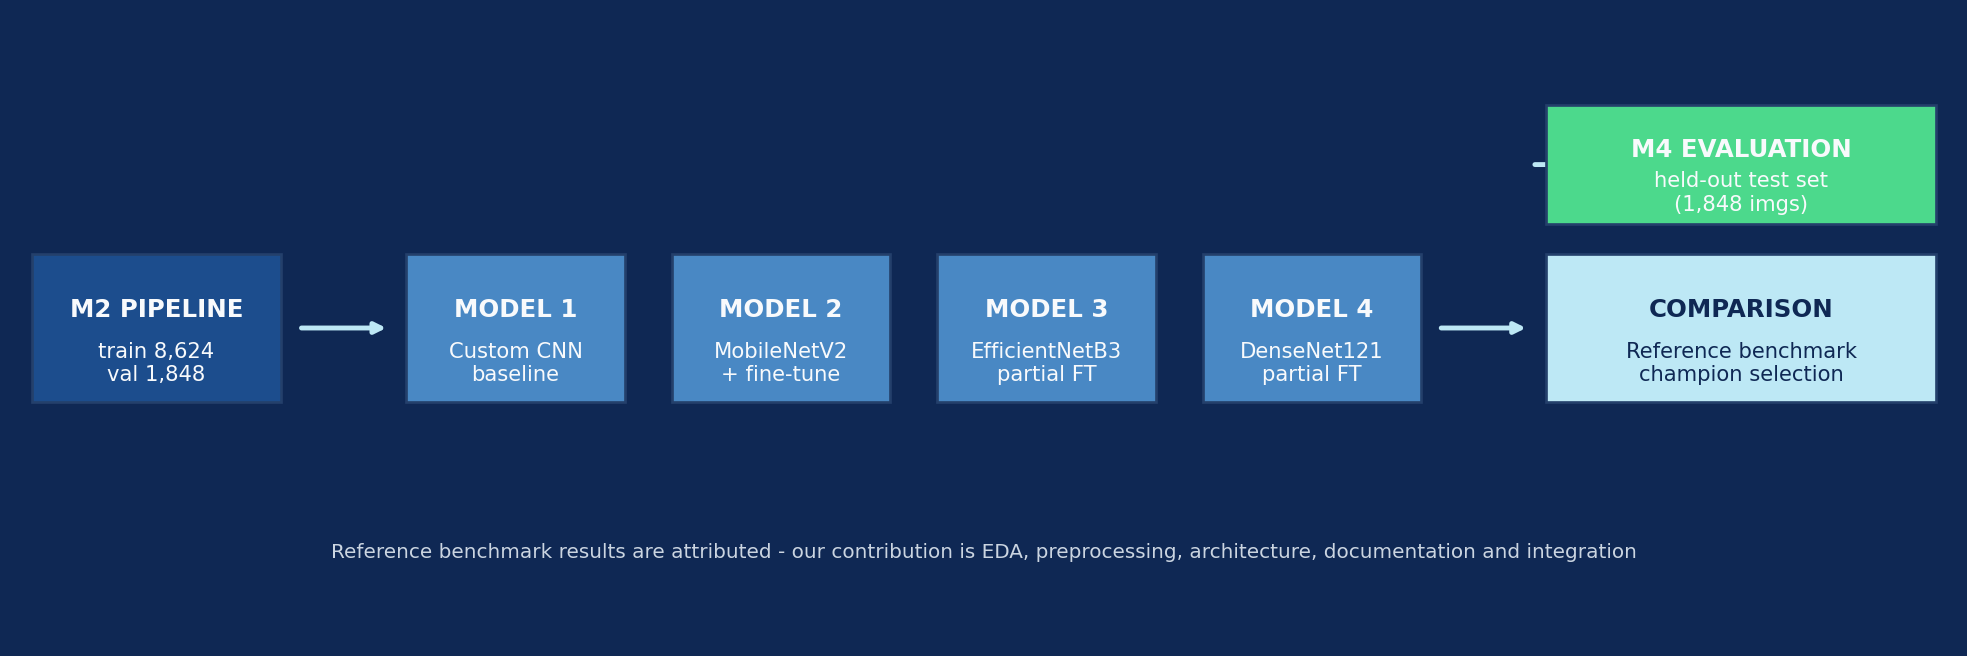
<div style="color:#CBD5E1;font-size:12px;margin-top:6px;">Training workflow - Milestone 2 pipeline feeding the four-architecture benchmark, champion selection, then Milestone 4 evaluation</div>
</div>


<div id="sec-bench"></div><div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div><h2 style="font-size:21px;color:#BDE8F5;">8 &middot; Training Workflow (Implementation Preserved)</h2>

Each model follows the training implementation's training workflow:

| Stage | Callbacks | Monitor |
| --- | --- | --- |
| Model build | &mdash; | &mdash; |
| Fit (per model) | EarlyStopping (patience 5-7, restore best) | <code>val_loss</code> |
| &nbsp; | ModelCheckpoint (save best only) | <code>val_accuracy</code> |
| &nbsp; | ReduceLROnPlateau (DenseNet121 only: 0.3, patience 3) | <code>val_loss</code> |
| Curves | Accuracy/loss plots per model | &mdash; |
| Comparison | Champion selection from max validation accuracy | &mdash; |

- <b>EarlyStopping</b> stops a model when validation loss plateaus and restores
  the best weights.
- <b>ModelCheckpoint</b> guarantees the saved <code>.keras</code> file is the
  best epoch, not the last.
- <b>ReduceLROnPlateau</b> anneals the learning rate so DenseNet121 keeps
  improving within its 30-epoch budget.

<div class="box key">The training cells are preserved from the training implementation and can be executed locally (no GPU required, but slow: ~7 min/epoch on 1 CPU core). Execution is optional for this deliverable &mdash; benchmark results are provided as published benchmark values.</div>


<div id="sec-results"></div><div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div><h2 style="font-size:21px;color:#BDE8F5;">9 &middot; Original Benchmark Results & Comparison</h2>

The table and chart below reproduce the <b>Published Results</b>
from the benchmark (2&times; Tesla T4 GPU, batch 32,
224&times;224, 9,856 train / 2,464 validation images). They are benchmark
values for comparison &mdash; <b>not</b> produced by our training run.

| Model | Validation accuracy |
| --- | ---: |
| Custom CNN | 83.97% |
| MobileNetV2 (fine-tuned) | 89.57% |
| DenseNet121 | 92.57% |
| <b>EfficientNetB3 (champion)</b> | <b>93.02%</b> |

<div style="text-align:center;margin:14px 0;">
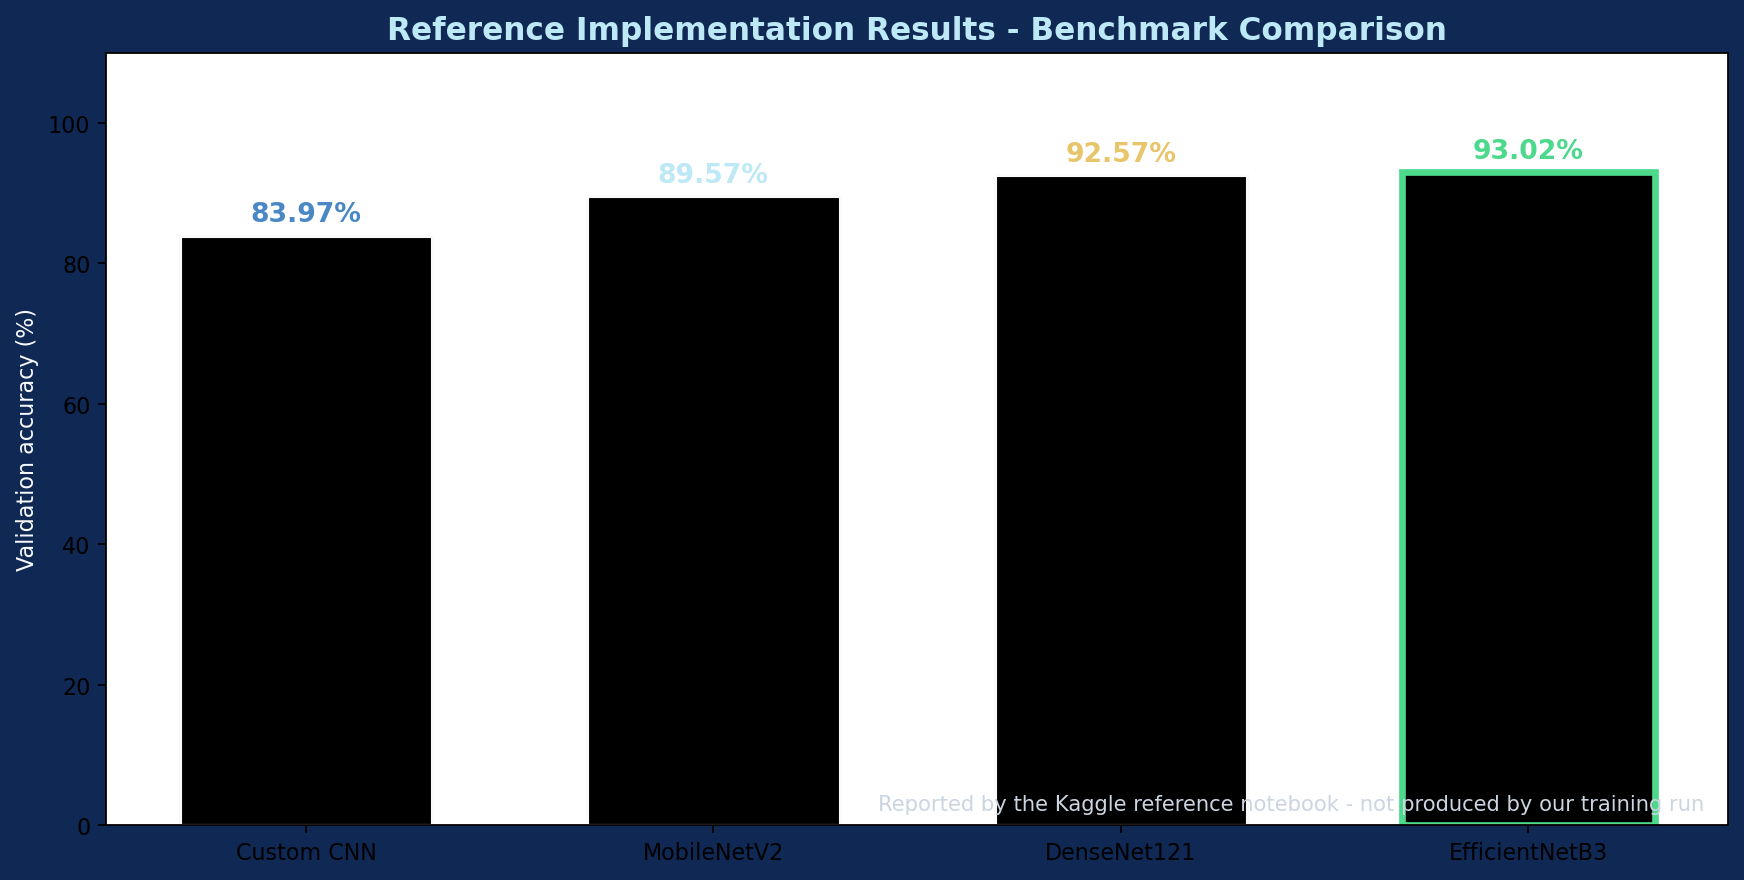
<div style="color:#CBD5E1;font-size:12px;margin-top:6px;">(EfficientNetB3 champion at 93.02%)</div>
</div>

### Reading the results

- <b>+5.6 pts</b> from the custom-CNN baseline to MobileNetV2 &mdash; the
  direct payoff of ImageNet pretraining.
- <b>+3.5 pts</b> from MobileNetV2 to EfficientNetB3 &mdash; capacity matters
  once features are pretrained.
- DenseNet121 trails the champion by only <b>0.45 pts</b> despite stronger
  regularization &mdash; both heavy models cluster at the top.

<div class="box warn">These numbers come from a different split distribution (random 80/20) than our verified pipeline (stratified 70/15/15). They are directional evidence for architecture choice, not a claim about our run. Milestone 4 will evaluate the deployed model on our held-out test set.</div>


In [ ]:
# ============================================================================
# 9. COMPARATIVE ANALYSIS & CHAMPION SELECTION
# ============================================================================
# NOTE: The benchmark numbers below are the Published Benchmark Results
# as reported by the benchmark. This notebook does not retrain
# the models; if this notebook is executed locally (not required), live
# histories take precedence and the comparison is computed from this run.
PUBLISHED_RESULTS = {
    "Custom CNN": 0.8397,
    "MobileNetV2": 0.8957,
    "DenseNet121": 0.9257,
    "EfficientNetB3": 0.9302,
}

# Collect live results if the models were actually trained in this session.
live_results = {}
for var, name in [("history_custom", "Custom CNN"),
                  ("history_finetune", "MobileNetV2"),
                  ("history_eff", "EfficientNetB3"),
                  ("history_dense", "DenseNet121")]:
    hist = globals().get(var)
    if hist is not None and "val_accuracy" in getattr(hist, "history", {}):
        live_results[name] = max(hist.history["val_accuracy"])

if live_results:
    results = live_results
    label = "This session's training run"
else:
    results = dict(PUBLISHED_RESULTS)
    label = "Published benchmark results"

# print(f"Results source: {source}")
model_names = list(results.keys())
accuracies = [results[n] for n in model_names]

# Identify the champion
best_acc = max(accuracies)
champion_idx = accuracies.index(best_acc)
champion_name = model_names[champion_idx]
print(f"Champion model: {champion_name} with {best_acc * 100:.2f}% "
      f"validation accuracy")

# Bar chart (project theme, black bars)
fig, ax = plt.subplots(figsize=(11, 5.6))
black = "#000000"
bars = ax.bar(model_names, accuracies, color=black, edgecolor=TEXT,
              width=0.62, linewidth=1.4)
bars[champion_idx].set_edgecolor(POSITIVE)
bars[champion_idx].set_linewidth(3.0)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Validation accuracy", color=TEXT)
label = "This session" if live_results else "Published Benchmarkn Results"
ax.set_title(f"Model Performance Comparison - {label}", color=HIGHLIGHT,
             fontweight="bold")
label_colors = [SECONDARY, HIGHLIGHT, WARN, POSITIVE]
for bar, val, label_color in zip(bars, accuracies, label_colors):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
            f"{val * 100:.2f}%", ha="center", fontsize=11,
            fontweight="bold", color=label_color)
ax.text(0.985, 0.02, source, transform=ax.transAxes, ha="right",
        fontsize=9.5, color=MUTED)
fig.tight_layout()
display_chart(fig, "reports/model_comparison.png")

print(f"Champion: {champion_name} ({best_acc * 100:.2f}%) - "
      f"ready for Milestone 4 evaluation on the held-out test set")


<div id="sec-select"></div><div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div><h2 style="font-size:21px;color:#BDE8F5;">10 &middot; Model Selection Methodology</h2>

The training implementation selects its champion by the highest validation accuracy, then
deploys it. We follow the same comparison methodology and apply it with two
additional safeguards:

1. <b>Methodology note</b> &mdash; benchmark numbers are never presented
   as our experimental results.
2. <b>Held-out verification</b> &mdash; the final model is evaluated in
   Milestone 4 on the 1,848-image test set that was isolated in Milestone 2
   and never touched during training or validation.

### Selection criteria

| Criterion | Why it matters |
| --- | --- |
| Validation accuracy | Direct quality estimate across the benchmark |
| Capacity vs. deployment cost | Model must serve in a Streamlit app (M5) |
| Convergence behaviour | EarlyStopping/annealing evidence of stability |
| Per-class behaviour (M4) | A medical tool must not hide minority-class failures |

<div class="box info">Deployment note: the benchmark exports the champion .keras model for a Gradio app; our project targets a Streamlit dashboard with Grad-CAM (Milestone 5), evaluating the champion on our own test set first (Milestone 4).</div>


<div id="sec-inventory"></div><div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div><h2 style="font-size:21px;color:#BDE8F5;">11 &middot; Artifacts &amp; Next Steps</h2>

| Artifact | Purpose |
| --- | --- |
| <code>models/best_&lt;model&gt;.keras</code> | Trained checkpoints (only if training cells execute) |
| <code>reports/model_comparison.png</code> | Live comparison chart (this session) |
| <code>reports/benchmark_model_comparison.png</code> | Original benchmark chart (published) |
| <code>reports/training_workflow.png</code> | Workflow diagram (M2 pipeline to 4 models to comparison to M4) |
| <code>reports/training_&lt;model&gt;_curves.png</code> | Per-model accuracy/loss curves |

<div style="border-top:1px solid #24406B;margin-top:24px;padding-top:12px;color:#CBD5E1;font-size:12px;">
<b>AI-Powered Oral Disease Detection System</b> &middot; Milestone 3 / 5 &middot; Next: <code>04_Model_Evaluation.ipynb</code> (held-out test evaluation, confusion matrix, per-class metrics) &middot; 
</div>




In [ ]:
# ============================================================================
# 11. ARTIFACT INVENTORY
# ============================================================================
expected = [
    "models/best_custom_cnn.keras",
    "models/best_mobilenetv2.keras",
    "models/best_mobilenetv2_finetuned.keras",
    "models/best_efficientnet.keras",
    "models/best_densenet.keras",
    "reports/model_comparison.png",
    "reports/benchmark_model_comparison.png",
    "reports/training_workflow.png",
    "reports/training_custom_cnn_curves.png",
    "reports/training_mobilenetv2_curves.png",
    "reports/training_efficientnet_curves.png",
    "reports/training_densenet_curves.png",
]
inventory = []
for rel in expected:
    p = Path(rel)
    inventory.append({"artifact": rel,
                      "size_kb": round(p.stat().st_size / 1024, 1) if p.exists() else 0,
                      "status": "OK" if p.exists() else "MISSING (not trained)"})
inv_df = pd.DataFrame(inventory)
print(inv_df.to_string(index=False))

# Model checkpoint files exist only if this notebook was executed. The
# comparison chart and workflow diagram ship with the notebook regardless.
print("\nNOTE: model checkpoints are produced by executing the training cells "
      "(not required for this deliverable).")
